**Instructor Performance and Course Quality Evaluation on EduPro**

**Objective**

This project evaluates instructor effectiveness, course quality, and enrollment behavior on the EduPro platform using exploratory data analysis and visualization techniques.

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab


**Dataset Sheets**
- Teachers
- Courses
- Transactions
- Users

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

**Load Dataset**

In [2]:
excel_file = pd.ExcelFile("/content/EduPro Dataset.xlsx")
print(excel_file.sheet_names)

['Users', 'Teachers', 'Courses', 'Transactions']


In [3]:
teachers = pd.read_excel("/content/EduPro Dataset.xlsx", sheet_name="Teachers")
courses = pd.read_excel("/content/EduPro Dataset.xlsx", sheet_name="Courses")
transactions = pd.read_excel("/content/EduPro Dataset.xlsx", sheet_name="Transactions")
users = pd.read_excel("/content/EduPro Dataset.xlsx", sheet_name="Users")

**Dataset Overview**

In [4]:
print("Teachers Shape:", teachers.shape)
print("Courses Shape:", courses.shape)
print("Transactions Shape:", transactions.shape)
print("Users Shape:", users.shape)

Teachers Shape: (60, 7)
Courses Shape: (60, 8)
Transactions Shape: (10000, 7)
Users Shape: (3000, 5)


In [5]:
teachers.head()

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


**Descriptive Statistics of Teachers and Courses**

In [6]:
teachers.describe()

,Age,YearsOfExperience,TeacherRating
count,60.000000,60.000000,60.000000
mean,38.450000,6.283333,3.125000
std,7.703015,4.715972,0.949797
min,27.000000,1.000000,1.050000
25%,32.000000,3.000000,2.487500
50%,36.500000,6.000000,3.275000
75%,46.250000,8.000000,3.827500
max,50.000000,24.000000,4.970000


In [7]:
courses.describe()

,CoursePrice,CourseDuration,CourseRating
count,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833
std,153.601506,16.092578,1.171232
min,0.000000,1.200000,1.130000
25%,0.000000,14.500000,2.107500
50%,0.000000,28.505000,3.065000
75%,133.615000,43.012500,4.102500
max,490.900000,49.730000,4.940000


**Missing Values Check**

In [8]:
teachers.isnull().sum()

,0
TeacherID,0
TeacherName,0
Age,0
Gender,0
Expertise,0
YearsOfExperience,0
TeacherRating,0


In [9]:
courses.isnull().sum()

,0
CourseID,0
CourseName,0
CourseCategory,0
CourseType,0
CourseLevel,0
CoursePrice,0
CourseDuration,0
CourseRating,0


In [10]:
transactions.isnull().sum()

,0
TransactionID,0
UserID,0
CourseID,0
TransactionDate,0
Amount,0
PaymentMethod,0
TeacherID,0


In [11]:
users.isnull().sum()

,0
UserID,0
UserName,0
Age,0
Gender,0
Email,0


**Teacher Rating Distribution**

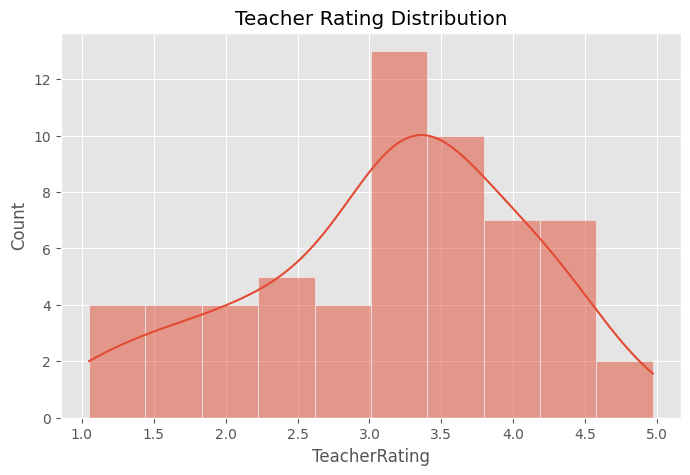

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(
    teachers["TeacherRating"],
    bins=10,
    kde=True)
plt.title("Teacher Rating Distribution")
plt.show()

**Experience Distribution**

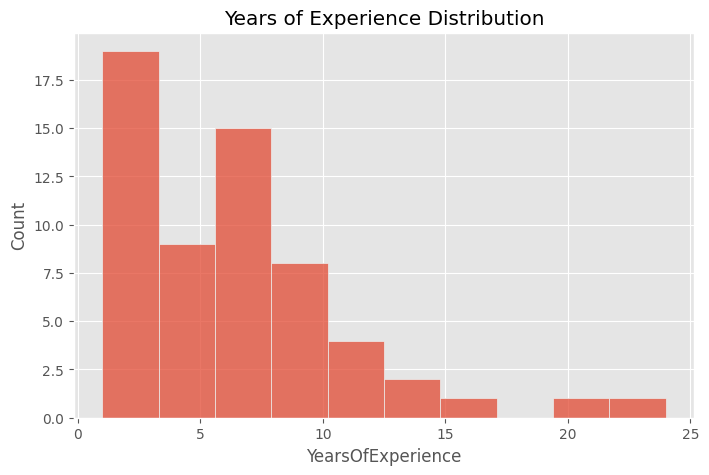

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(
    teachers["YearsOfExperience"],
    bins=10)
plt.title("Years of Experience Distribution")
plt.show()

**Experience vs Rating**

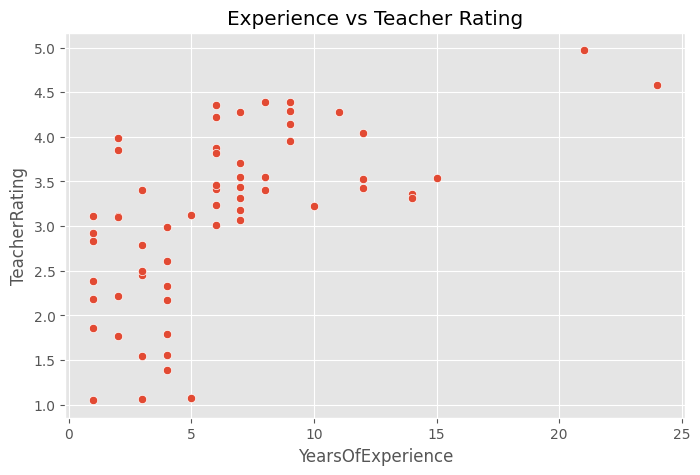

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=teachers,
    x="YearsOfExperience",
    y="TeacherRating")
plt.title("Experience vs Teacher Rating")
plt.show()

**Expertise-wise Average Rating**

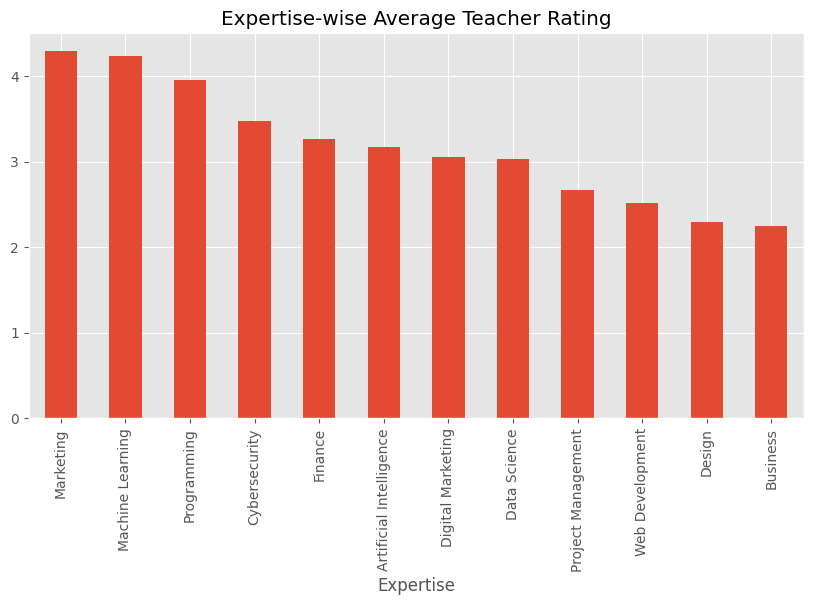

In [15]:
expertise_rating = (
    teachers.groupby("Expertise")
    ["TeacherRating"]
    .mean()
    .sort_values(ascending=False))
plt.figure(figsize=(10,5))
expertise_rating.plot(kind="bar")
plt.title("Expertise-wise Average Teacher Rating")
plt.show()

**Course Category vs Course Rating**

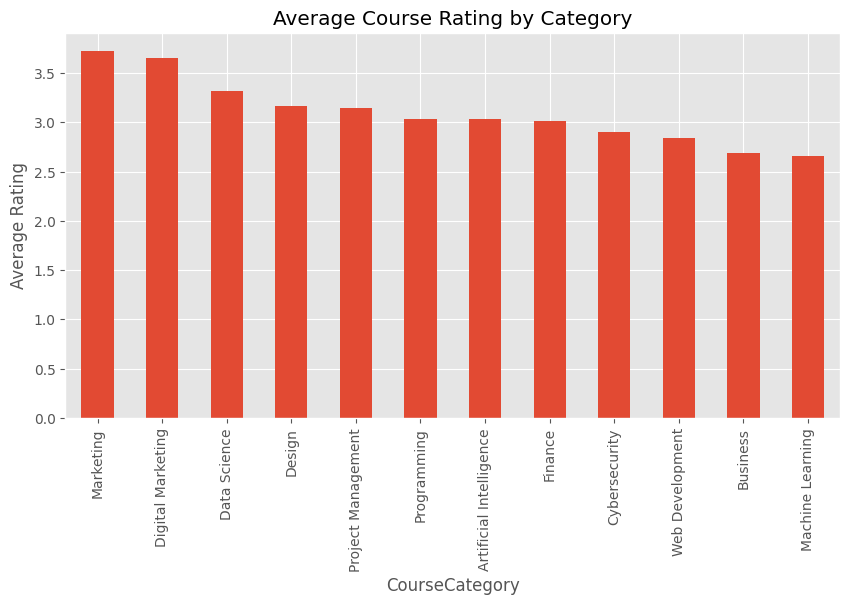

In [16]:
category_rating = (
    courses.groupby("CourseCategory")
    ["CourseRating"]
    .mean()
    .sort_values(ascending=False))
plt.figure(figsize=(10,5))
category_rating.plot(kind="bar")
plt.title("Average Course Rating by Category")
plt.ylabel("Average Rating")
plt.show()

**Course Level vs Course Rating**

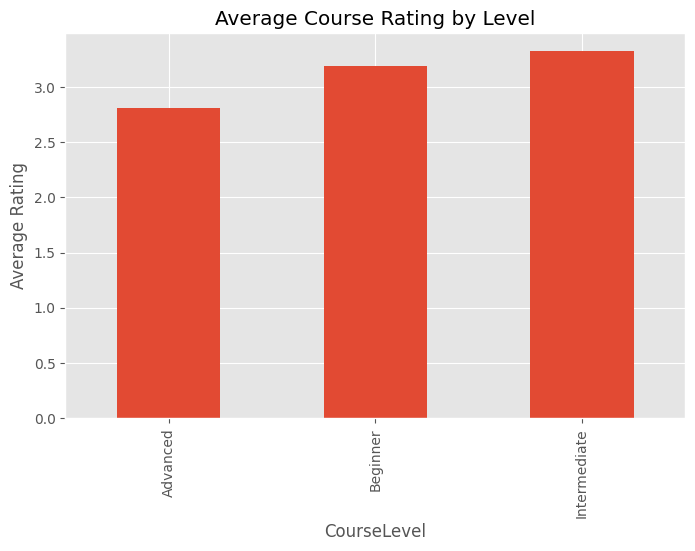

In [17]:
level_rating = (
    courses.groupby("CourseLevel")
    ["CourseRating"]
    .mean())
plt.figure(figsize=(8,5))
level_rating.plot(kind="bar")
plt.title("Average Course Rating by Level")
plt.ylabel("Average Rating")
plt.show()

**Course Quality Heatmap**

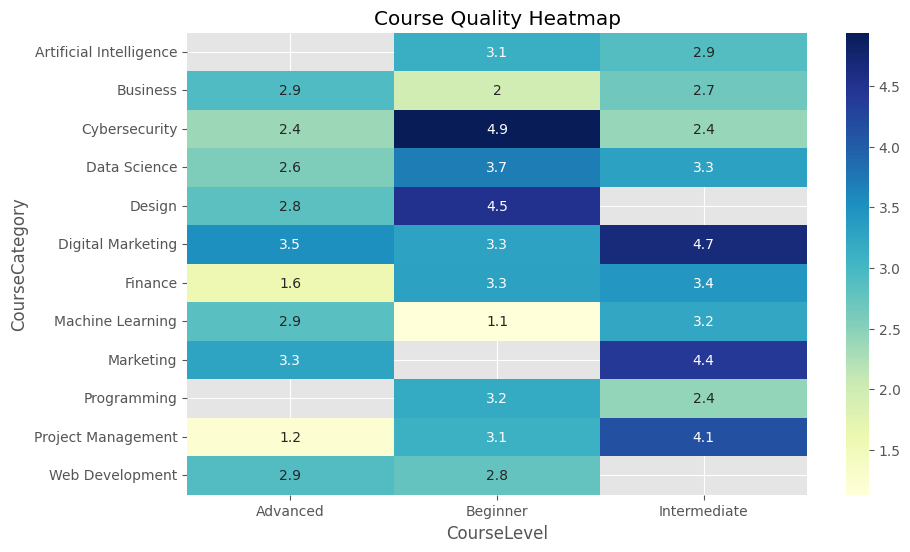

In [18]:
heatmap_data = courses.pivot_table(
    values="CourseRating",
    index="CourseCategory",
    columns="CourseLevel",
    aggfunc="mean")
plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu")
plt.title("Course Quality Heatmap")
plt.show()

**Teacher Rating vs Course Rating Analysis**

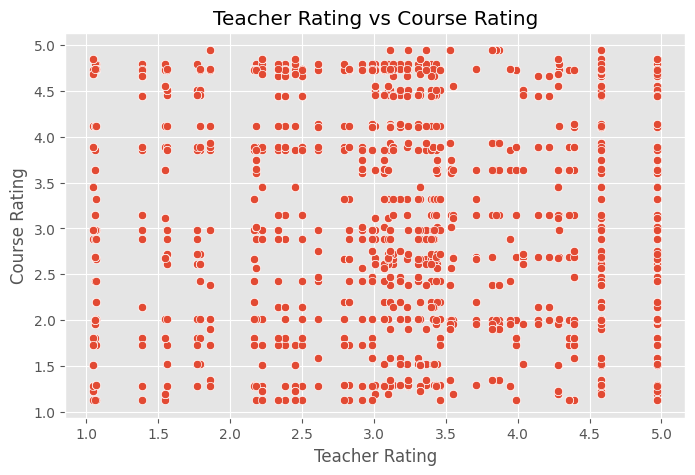

Pearson Correlation Coefficient: -0.002
Insight: Weak relationship between Teacher Rating and Course Rating


In [38]:
teacher_course = transactions.merge(
    teachers[['TeacherID', 'TeacherRating']],
    on='TeacherID').merge(
    courses[['CourseID', 'CourseRating']],
    on='CourseID')
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=teacher_course,
    x='TeacherRating',
    y='CourseRating')
plt.title('Teacher Rating vs Course Rating')
plt.xlabel('Teacher Rating')
plt.ylabel('Course Rating')
plt.show()
corr_value = (
    teacher_course[['TeacherRating', 'CourseRating']]
    .corr()
    .iloc[0,1])
print(f"Pearson Correlation Coefficient: {corr_value:.3f}")
if abs(corr_value) < 0.3:
    print("Insight: Weak relationship between Teacher Rating and Course Rating")
elif abs(corr_value) < 0.7:
    print("Insight: Moderate relationship between Teacher Rating and Course Rating")
else:
    print("Insight: Strong relationship between Teacher Rating and Course Rating")

**Analysis Insight**

The correlation analysis evaluates the relationship between instructor ratings and course ratings. The results indicate that teacher ratings and course ratings exhibit a weak relationship, suggesting that course quality may also be influenced by factors such as course content, structure, learner engagement, and category-specific characteristics in addition to instructor performance.

**Instructor Leaderboard**

**Top 10 Instructors**

In [20]:
top_teachers = (
    teachers.sort_values(
        by="TeacherRating",
        ascending=False)
    .head(10))
top_teachers[
    ["TeacherName","Expertise","TeacherRating"]]

,TeacherName,Expertise,TeacherRating
41,Yolanda Levine,Machine Learning,4.97
39,Kimberly Miller,Cybersecurity,4.58
3,Kristi Scott,Machine Learning,4.39
36,Debra Escobar,Finance,4.39
6,Angela Beard,Machine Learning,4.36
52,Aaron Kirby,Marketing,4.29
17,Kari Pierce,Project Management,4.28
53,Shelby Patrick,Artificial Intelligence,4.28
23,Michael Kim,Digital Marketing,4.22
1,Jill Day,Digital Marketing,4.14


**Bottom 10 Teachers**

In [21]:
bottom_teachers = (
    teachers.sort_values(
        by="TeacherRating",
        ascending=True)
    .head(10))
bottom_teachers[
    ["TeacherName","Expertise","TeacherRating"]]

,TeacherName,Expertise,TeacherRating
42,John Williams,Project Management,1.05
27,Timothy Bailey,Business,1.06
44,Emily Gutierrez,Web Development,1.07
35,Brenda Mclean,Digital Marketing,1.39
26,Laurie Michael,Artificial Intelligence,1.55
2,Amber Torres,Design,1.56
50,John Obrien,Design,1.77
46,Brad Griffin,Design,1.79
30,Brenda Mercer,Cybersecurity,1.86
24,Justin Pham,Web Development,2.17


**KPI Calculation**

In [22]:
print("Average Teacher Rating:",
      round(teachers["TeacherRating"].mean(),2))
print("Average Course Rating:",
      round(courses["CourseRating"].mean(),2))
print("Average Experience:",
      round(teachers["YearsOfExperience"].mean(),2))
print("Total Courses:",
      len(courses))
print("Total Teachers:",
      len(teachers))
print("Total Transactions:",
      len(transactions))

Average Teacher Rating: 3.12
Average Course Rating: 3.1
Average Experience: 6.28
Total Courses: 60
Total Teachers: 60
Total Transactions: 10000


**Descriptive Statistical Analysis**

In [23]:
teachers.describe()

,Age,YearsOfExperience,TeacherRating
count,60.000000,60.000000,60.000000
mean,38.450000,6.283333,3.125000
std,7.703015,4.715972,0.949797
min,27.000000,1.000000,1.050000
25%,32.000000,3.000000,2.487500
50%,36.500000,6.000000,3.275000
75%,46.250000,8.000000,3.827500
max,50.000000,24.000000,4.970000


In [24]:
courses.describe()

,CoursePrice,CourseDuration,CourseRating
count,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833
std,153.601506,16.092578,1.171232
min,0.000000,1.200000,1.130000
25%,0.000000,14.500000,2.107500
50%,0.000000,28.505000,3.065000
75%,133.615000,43.012500,4.102500
max,490.900000,49.730000,4.940000


**Additional Analysis**

**Merge Teachers + Transactions**

In [25]:
teacher_transactions = transactions.merge(
    teachers,
    on="TeacherID",
    how="left")

**Enrollment Count by Teacher**

In [26]:
teacher_enrollment = (
    teacher_transactions.groupby(
        ["TeacherName","TeacherRating"])
    .size()
    .reset_index(name="EnrollmentCount"))
teacher_enrollment.head()

,TeacherName,TeacherRating,EnrollmentCount
0,Aaron Kirby,4.29,120
1,Adam Holmes,3.99,51
2,Alexander Tucker,2.22,58
3,Alexander Williams,3.41,24
4,Alexis Everett,3.95,123


**Teacher Rating vs Enrollment**

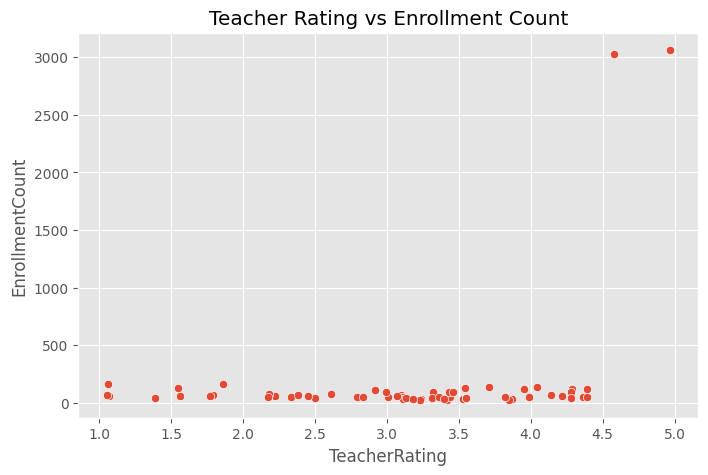

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=teacher_enrollment,
    x="TeacherRating",
    y="EnrollmentCount")
plt.title("Teacher Rating vs Enrollment Count")
plt.show()

**Enrollment by Expertise**

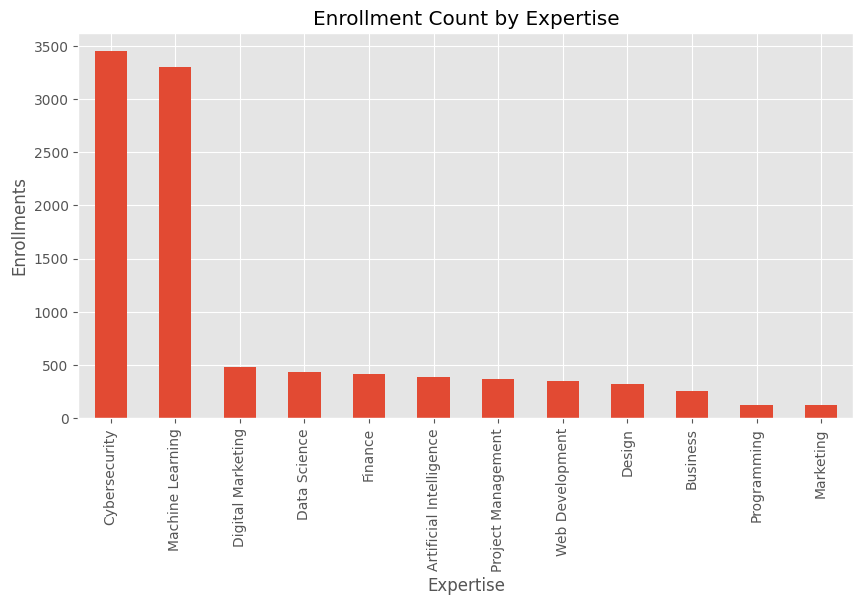

In [28]:
expertise_enrollment = (
    teacher_transactions.groupby("Expertise")
    .size()
    .sort_values(ascending=False))
plt.figure(figsize=(10,5))
expertise_enrollment.plot(kind="bar")
plt.title("Enrollment Count by Expertise")
plt.ylabel("Enrollments")
plt.show()

**Teacher Age Distribution Analysis**

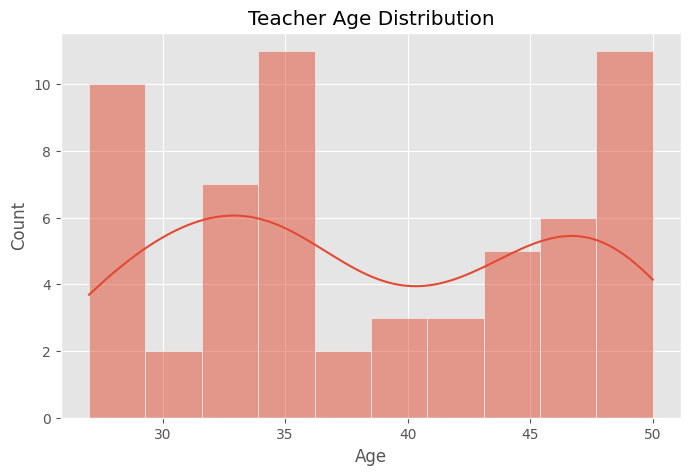

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(
    teachers["Age"],
    bins=10,
    kde=True)
plt.title("Teacher Age Distribution")
plt.show()

**Correlation Analysis of Teacher Metrics**

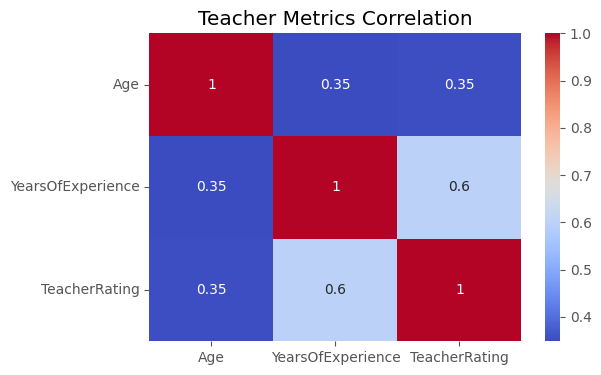

In [30]:
numeric_cols = teachers[
    ["Age",
     "YearsOfExperience",
     "TeacherRating"]]
plt.figure(figsize=(6,4))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm")
plt.title("Teacher Metrics Correlation")
plt.show()

**Correlation Insight**

- TeacherRating shows a positive relationship with YearsOfExperience.
- Age and experience are moderately associated.
- Experience appears to contribute positively toward instructor quality.

**Teacher Rating Analysis by Gender**

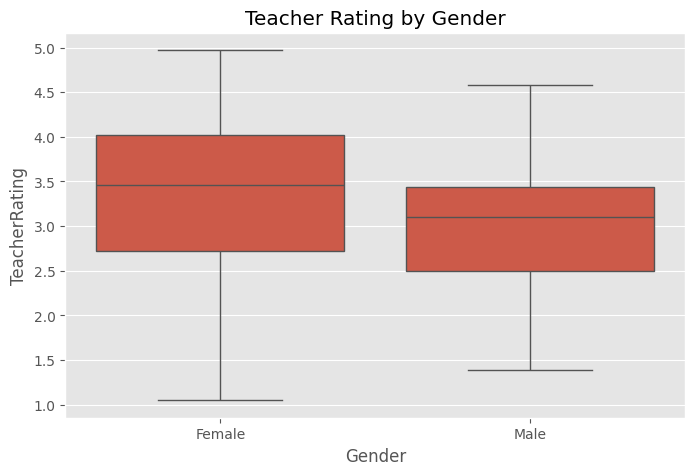

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=teachers,
    x="Gender",
    y="TeacherRating")
plt.title("Teacher Rating by Gender")
plt.show()

**Rating Consistency Analysis**

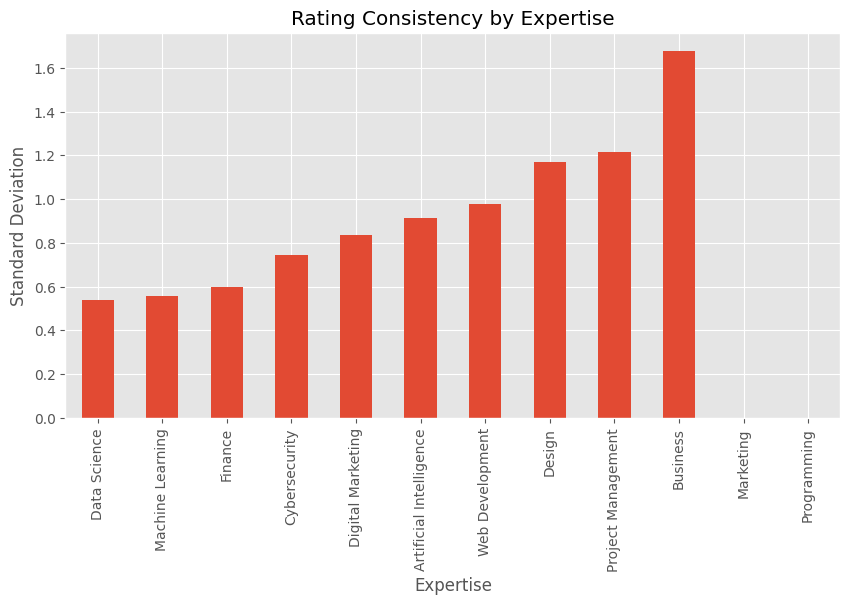

,TeacherRating
Expertise,
Data Science,0.539537
Machine Learning,0.556893
Finance,0.600591
Cybersecurity,0.745762
Digital Marketing,0.837269


In [32]:
rating_consistency = (
    teachers.groupby("Expertise")["TeacherRating"]
    .std()
    .sort_values())
plt.figure(figsize=(10,5))
rating_consistency.plot(kind="bar")
plt.title("Rating Consistency by Expertise")
plt.ylabel("Standard Deviation")
plt.show()
rating_consistency.head()

**Rating Consistency Insight**

Lower standard deviation indicates more consistent instructor ratings within an expertise domain. Data Science and Machine Learning exhibit the most consistent performance, while Finance demonstrates greater variation in instructor ratings.

**Enrollment Analysis by Teacher Rating Tier**

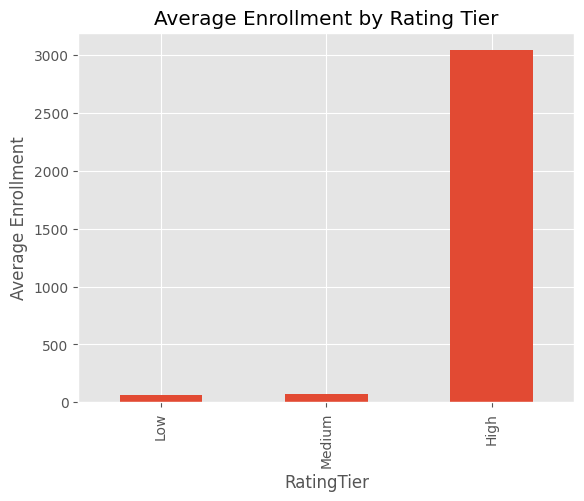

In [33]:
teacher_enrollment["RatingTier"] = pd.cut(
    teacher_enrollment["TeacherRating"],
    bins=[0,3.5,4.5,5],
    labels=["Low","Medium","High"])
tier_enrollment = (
    teacher_enrollment.groupby("RatingTier")
    ["EnrollmentCount"]
    .mean())
tier_enrollment.plot(kind="bar")
plt.title("Average Enrollment by Rating Tier")
plt.ylabel("Average Enrollment")
plt.show()

**Course Price and Rating Relationship Analysis**

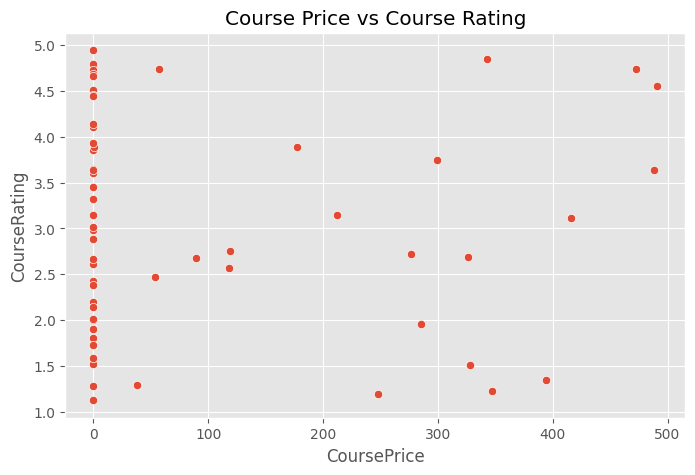

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=courses,
    x="CoursePrice",
    y="CourseRating")
plt.title("Course Price vs Course Rating")
plt.show()

**User Age Distribution Analysis**

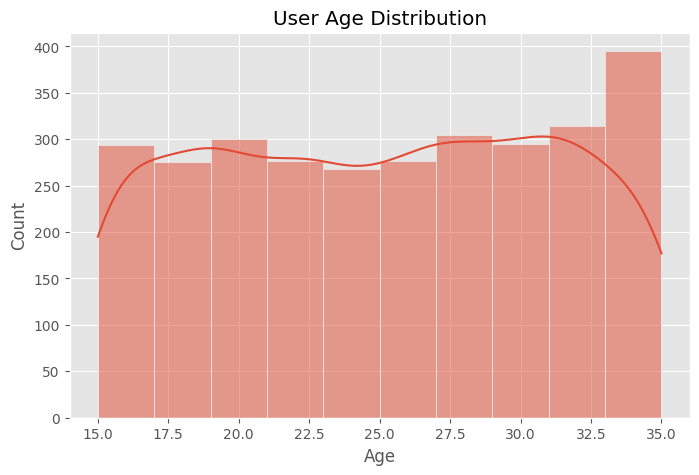

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(
    users["Age"],
    bins=10,
    kde=True)
plt.title("User Age Distribution")
plt.show()

**Key Findings**

1. Teacher experience shows a positive relationship with instructor ratings.
2. Certain expertise domains consistently achieve higher learner ratings.
3. Intermediate level courses receive the highest average ratings.
4. Highly rated instructors tend to attract greater enrollments.
5. Course quality varies across categories and expertise areas.

**Recommendations**

1. Invest in instructor development programs.
2. Prioritize high-performing expertise domains.
3. Replicate teaching practices of top-rated instructors.
4. Monitor low-performing categories for quality improvement.
5. Use instructor ratings as a key quality benchmark.

**Executive Insights**

**Key Business Observations**

1. Teaching experience demonstrates a positive association with instructor ratings.

2. High-performing instructors contribute significantly to enrollment growth.

3. Certain expertise domains consistently achieve higher learner satisfaction scores.

4. Course quality varies across categories and learning levels.

5. Instructor quality serves as a leading indicator of course success.

**Strategic Actions**

- Develop mentorship programs for new instructors.
- Expand courses within high-performing expertise domains.
- Establish continuous instructor evaluation systems.
- Monitor low-performing categories for quality improvement.
- Reward top-rated instructors through recognition programs.

**Research Summary**

This study evaluated instructor performance and course quality using instructor demographics, expertise, experience, enrollment behavior, and course ratings.

Key outcomes indicate that instructor experience positively influences ratings, while highly rated instructors attract greater enrollment volumes. Expertise domains also demonstrate measurable differences in performance and learner satisfaction.

The findings support the implementation of a structured instructor evaluation framework for improving educational quality and learner outcomes.

**Conclusion**

The analysis demonstrates that instructor quality has a measurable impact on course performance and learner engagement. Experienced instructors generally achieve higher ratings, while high-rated instructors attract greater enrollment volumes. Expertise domains also show significant variation in performance. These findings support the adoption of a data-driven instructor evaluation framework for improving educational outcomes on the EduPro platform.